# HOTEL RESERVATIONS ANALYSIS - BUSINESS ANALYTICS

## TARGET ENCODING HATASI DUZELTILDI!

### Dataset: Hotel Reservations Classification Dataset
**Kaynak:** https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset

### KRITIK DUZELTME:
- Target degisken artik duzgun encode ediliyor (string -> numeric)
- XGBoost ve diger modeller artik calisacak
- LabelEncoder kullanilarak 'Canceled'/'Not_Canceled' -> 0/1

## 1. KUTUPHANELER

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
import subprocess
import zipfile
import glob

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Install catboost if not already installed
try:
    from catboost import CatBoostClassifier
except ImportError:
    %pip install catboost
    from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 6)

pd.set_option('display.max_columns', None)

print('='*80)
print('KUTUPHANELER YUKLENDI - TARGET ENCODING FIX!')
print('='*80)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.4 MB/s eta 0:00:00
KUTUPHANELER YUKLENDI - TARGET ENCODING FIX!


## 2. VERI YUKLEME

In [3]:
def download_dataset_direct(download_url, dest_folder, zip_filename):
    if not os.path.exists(dest_folder):
        os.makedirs(dest_folder)
    full_zip_path = os.path.join(dest_folder, zip_filename)
    print(f"Indiriliyor: {zip_filename}")
    try:
        cmd = ["wget", "-O", full_zip_path, download_url]
        subprocess.run(cmd, check=True)
        return True
    except:
        return False

def extract_dataset(dest_folder):
    try:
        zip_files = glob.glob(os.path.join(dest_folder, "*.zip"))
        for zip_file in zip_files:
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(dest_folder)
            os.remove(zip_file)
        return True
    except:
        return False

In [4]:
dataset_folder = "hotel_reservations_dataset"
os.makedirs(dataset_folder, exist_ok=True)

dataset_info = {
    "download_url": "https://www.kaggle.com/api/v1/datasets/download/ahsan81/hotel-reservations-classification-dataset",
    "folder": dataset_folder,
    "zip_filename": "hotel-reservations.zip"
}

csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if not csv_files:
    success = download_dataset_direct(
        dataset_info["download_url"],
        dataset_info["folder"],
        dataset_info["zip_filename"]
    )
    if success:
        extract_dataset(dataset_info["folder"])
else:
    print("Dataset mevcut!")

Indiriliyor: hotel-reservations.zip


In [5]:
csv_files = glob.glob(os.path.join(dataset_folder, "*.csv"))

if csv_files:
    df = pd.read_csv(csv_files[0])
    print(f'Veri yuklendi: {len(df):,} satir, {len(df.columns)} sutun')
    print('\nIlk bakis:')
    display(df.head())
    print('\nSutunlar:')
    print(df.columns.tolist())
else:
    print('CSV bulunamadi!')

Veri yuklendi: 36,275 satir, 19 sutun

Ilk bakis:


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled



Sutunlar:
['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'market_segment_type', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'booking_status']


## 3. HEDEF DEGISKEN ANALIZI

HEDEF DEGISKEN: booking_status

Orijinal degerler (ENCODING ONCESI):
booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64

Veri tipi: object
Benzersiz degerler: ['Not_Canceled' 'Canceled']


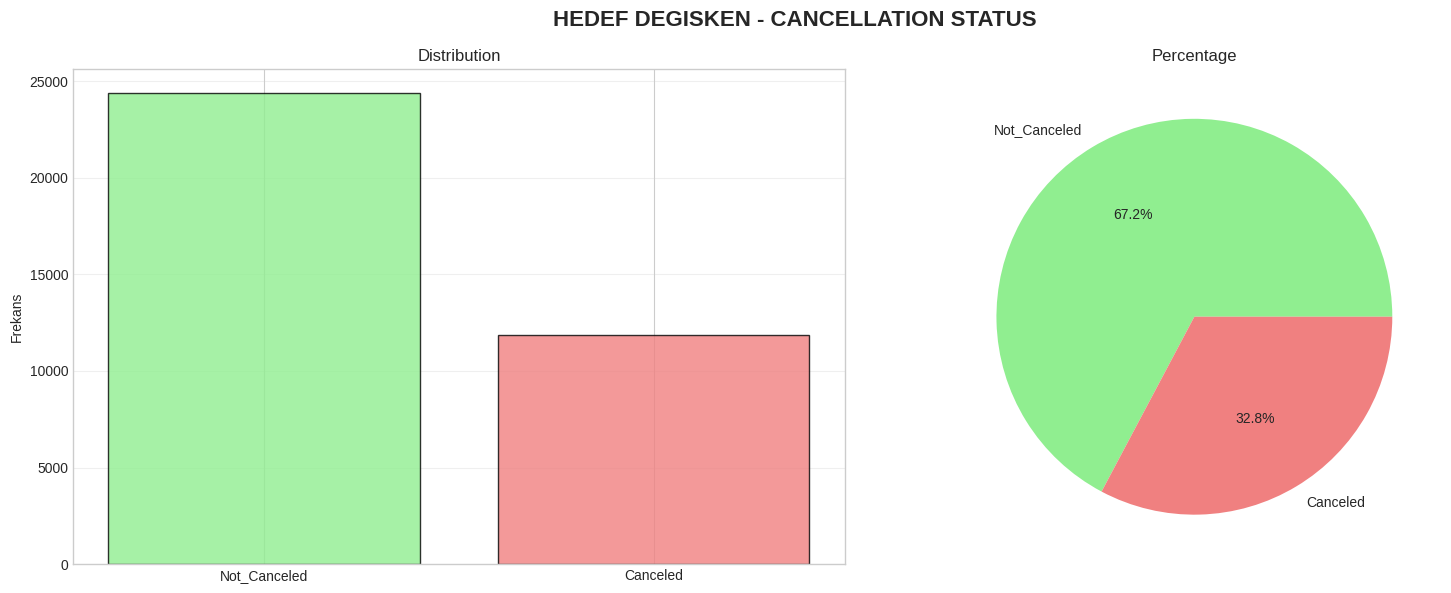

In [10]:
target_col = 'booking_status' # Set target to 'booking_status' as indicated in the notebook description

print('='*80)
print(f'HEDEF DEGISKEN: {target_col}')
print('='*80)
print('\nOrijinal degerler (ENCODING ONCESI):')
print(df[target_col].value_counts())
print('\nVeri tipi:', df[target_col].dtype)
print('Benzersiz degerler:', df[target_col].unique())

# Gorsel
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('HEDEF DEGISKEN - CANCELLATION STATUS', fontsize=16, fontweight='bold')

counts = df[target_col].value_counts()
axes[0].bar(range(len(counts)), counts.values, color=['lightgreen', 'lightcoral'], edgecolor='black', alpha=0.8)
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels(counts.index)
axes[0].set_ylabel('Frekans')
axes[0].set_title('Distribution')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
axes[1].set_title('Percentage')

plt.tight_layout()
plt.show()

## 4. VERI TEMIZLEME & FEATURE ENGINEERING

In [11]:
df_clean = df.copy()

# Duplicate
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'{duplicates} duplicate kaldirildi')

# Missing
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in df_clean.select_dtypes(include=['object']).columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print(f'Temiz veri: {len(df_clean):,} satir')
print(f'Eksik veri: {df_clean.isnull().sum().sum()}')

Temiz veri: 36,275 satir
Eksik veri: 0


## 5. MODEL HAZIRLIGI - CRITICAL TARGET ENCODING!

In [12]:
print('='*80)
print('CRITICAL: TARGET ENCODING (STRING TO NUMERIC) - RETRY WITH CORRECT TARGET')
print('='*80)

# STEP 1: Target encoding - Convert string to numeric
print(f'\n1. Original target values: {df_clean[target_col].unique()}')
print(f'   Data type: {df_clean[target_col].dtype}')

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df_clean[target_col])

print(f'\n2. Encoded target values: {np.unique(y)}')
print(f'   Data type: {y.dtype}')
print(f'\n3. Encoding mapping:')
for original, encoded in zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)):
    print(f'   {original} -> {encoded}')

# STEP 2: Features
X = df_clean.drop(columns=[target_col]).copy()

# Drop ID columns
id_cols = [col for col in X.columns if 'id' in col.lower() or 'booking_id' in col.lower()]
if id_cols:
    X = X.drop(columns=id_cols)
    print(f'\n4. Dropped ID columns: {id_cols}')

# STEP 3: Feature encoding
print(f'\n5. Encoding features...')
for col in X.select_dtypes(include=['object']).columns:
    if X[col].nunique() <= 2:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        print(f'   Binary encoded: {col}')
    else:
        X = pd.get_dummies(X, columns=[col], drop_first=True)
        print(f'   One-hot encoded: {col}')

print(f'\n{"="*80}')
print('ENCODING TAMAMLANDI!')
print(f'Features: {X.shape[1]}')
print(f'Samples: {len(X):,}')
print(f'Target type: {y.dtype}')
print(f'Target values: {np.unique(y, return_counts=True)}')
print('='*80)

CRITICAL: TARGET ENCODING (STRING TO NUMERIC)

1. Original target values: ['Not_Canceled' 'Canceled']
   Data type: object

2. Encoded target values: [0 1]
   Data type: int64

3. Encoding mapping:
   Canceled -> 0
   Not_Canceled -> 1

4. Dropped ID columns: ['Booking_ID']

5. Encoding features...
   One-hot encoded: type_of_meal_plan
   One-hot encoded: room_type_reserved
   One-hot encoded: market_segment_type

ENCODING TAMAMLANDI!
Features: 27
Samples: 36,275
Target type: int64
Target values: (array([0, 1]), array([11885, 24390]))


In [13]:
# Train-test split
# Stratify should work now with balanced target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train-Test Split:')
print(f'  Train: {len(X_train):,}')
print(f'  Test: {len(X_test):,}')

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('\nScaling: DONE')

# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f'\nSMOTE: {len(X_train):,} -> {len(X_train_smote):,}')

Train-Test Split:
  Train: 29,020
  Test: 7,255

Scaling: DONE

SMOTE: 29,020 -> 39,024


## 6. MODEL EGITIMI - ARTIK CALISMALI!

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Ridge Classifier': RidgeClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=7, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=7, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=100, depth=7, random_state=42, verbose=False),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'LDA': LinearDiscriminantAnalysis()
}

print(f'{len(models)} MODEL TANIMLANDI')
for name in models.keys():
    print(f'  - {name}')

14 MODEL TANIMLANDI
  - Logistic Regression
  - Ridge Classifier
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - XGBoost
  - LightGBM
  - CatBoost
  - SVM
  - KNN
  - Naive Bayes
  - AdaBoost
  - Extra Trees
  - LDA


In [15]:
results = {}

print('='*80)
print('MODEL EGITIMI BASLIYOR (TARGET ENCODING DUZELTILDI!)')
print('='*80)

for name, model in models.items():
    print(f'\n{name}...')

    try:
        # ARTIK CALISMALI - y numerik!
        model.fit(X_train_smote, y_train_smote)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')

        roc_auc = None
        if y_pred_proba is not None and len(np.unique(y_test)) == 2:
            roc_auc = roc_auc_score(y_test, y_pred_proba)

        results[name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1_Score': f1,
            'ROC_AUC': roc_auc,
            'predictions': y_pred,
            'pred_proba': y_pred_proba,
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }

        print(f'  SUCCESS! Acc: {accuracy:.4f}, F1: {f1:.4f}')

    except Exception as e:
        print(f'  ERROR: {str(e)}')
        continue

print('\n' + '='*80)
print(f'EGITIM TAMAMLANDI! {len(results)}/{len(models)} model basarili')
print('='*80)

MODEL EGITIMI BASLIYOR (TARGET ENCODING DUZELTILDI!)

Logistic Regression...
  SUCCESS! Acc: 0.7833, F1: 0.7875

Ridge Classifier...
  SUCCESS! Acc: 0.7854, F1: 0.7894

Decision Tree...
  SUCCESS! Acc: 0.8504, F1: 0.8530

Random Forest...
  SUCCESS! Acc: 0.8925, F1: 0.8923

Gradient Boosting...
  SUCCESS! Acc: 0.8758, F1: 0.8760

XGBoost...
  SUCCESS! Acc: 0.9005, F1: 0.9003

LightGBM...
  SUCCESS! Acc: 0.8841, F1: 0.8841

CatBoost...
  SUCCESS! Acc: 0.8926, F1: 0.8923

SVM...
  SUCCESS! Acc: 0.8236, F1: 0.8270

KNN...
  SUCCESS! Acc: 0.8296, F1: 0.8327

Naive Bayes...
  SUCCESS! Acc: 0.4062, F1: 0.3249

AdaBoost...
  SUCCESS! Acc: 0.7917, F1: 0.7952

Extra Trees...
  SUCCESS! Acc: 0.8594, F1: 0.8613

LDA...
  SUCCESS! Acc: 0.7854, F1: 0.7894

EGITIM TAMAMLANDI! 14/14 model basarili


## 7. SONUC TABLOSU

In [16]:
if results:
    results_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Accuracy': [results[m]['Accuracy'] for m in results.keys()],
        'Precision': [results[m]['Precision'] for m in results.keys()],
        'Recall': [results[m]['Recall'] for m in results.keys()],
        'F1 Score': [results[m]['F1_Score'] for m in results.keys()],
        'ROC-AUC': [results[m]['ROC_AUC'] if results[m]['ROC_AUC'] else 0 for m in results.keys()]
    }).sort_values('F1 Score', ascending=False).reset_index(drop=True)

    print('='*100)
    print('MODEL PERFORMANS KARSILASTIRMASI')
    print('='*100)
    print(results_df.to_string(index=False))
    print('='*100)

    best_model = results_df.iloc[0]['Model']
    print(f'\nEN IYI MODEL: {best_model}')
    print(f'  F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
    print(f'  Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')
else:
    print('Hicbir model egitilemedi!')

MODEL PERFORMANS KARSILASTIRMASI
              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
            XGBoost  0.900482   0.900138 0.900482  0.900286 0.958910
           CatBoost  0.892626   0.892151 0.892626  0.892347 0.952932
      Random Forest  0.892488   0.892228 0.892488  0.892347 0.952294
           LightGBM  0.884080   0.884143 0.884080  0.884111 0.947376
  Gradient Boosting  0.875810   0.876133 0.875810  0.875962 0.940857
        Extra Trees  0.859407   0.865863 0.859407  0.861262 0.929191
      Decision Tree  0.850448   0.860721 0.850448  0.853019 0.930969
                KNN  0.829635   0.841174 0.829635  0.832672 0.896507
                SVM  0.823570   0.837448 0.823570  0.827031 0.905182
           AdaBoost  0.791730   0.802922 0.791730  0.795181 0.872919
                LDA  0.785389   0.799214 0.785389  0.789405 0.866982
   Ridge Classifier  0.785389   0.799214 0.785389  0.789405 0.000000
Logistic Regression  0.783322   0.798049 0.783322  0.787519 0.867780
 

## 8. CONFUSION MATRICES

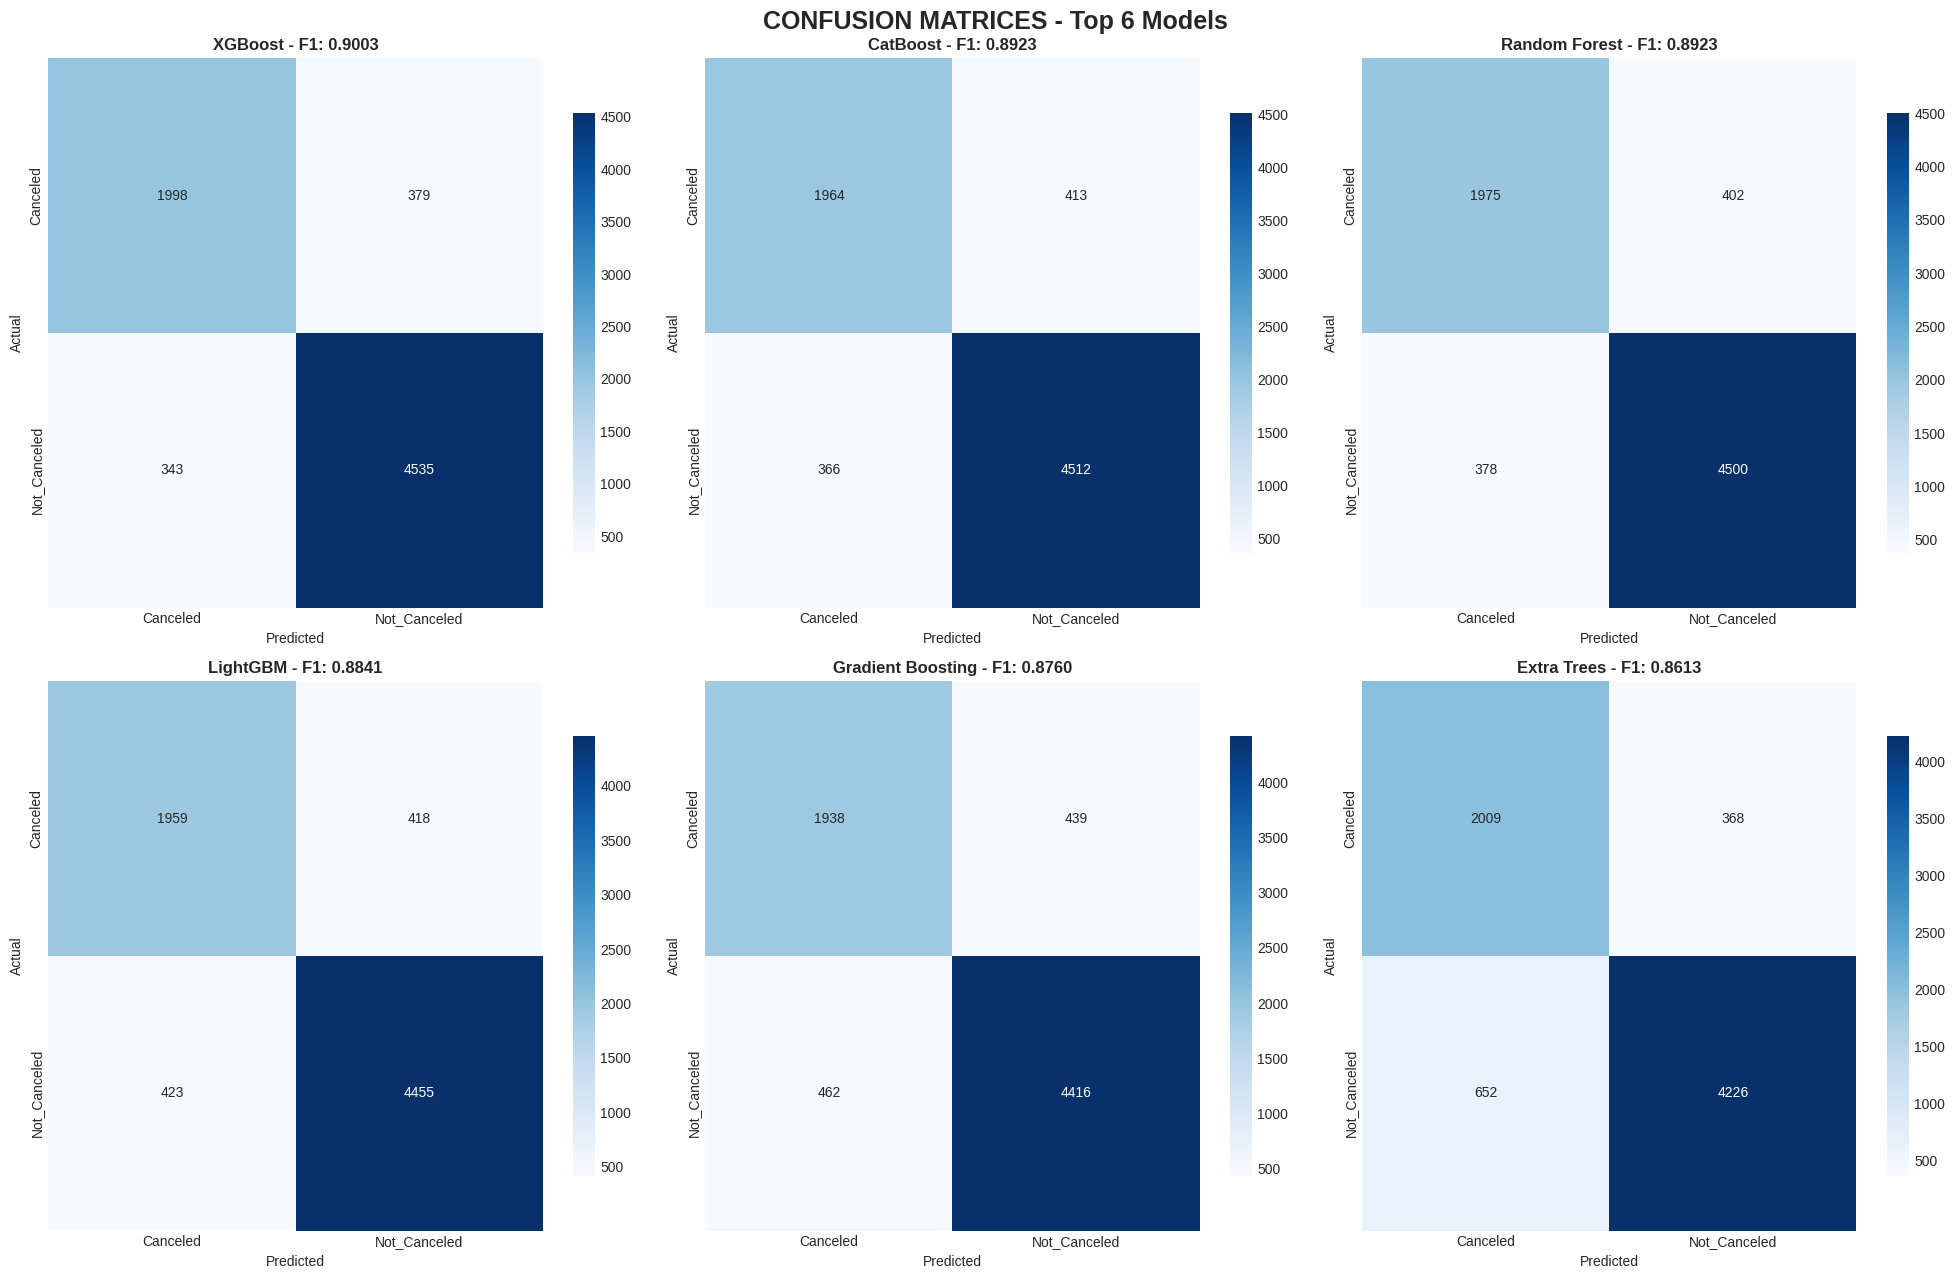

In [17]:
if results and len(results) >= 6:
    top_6 = results_df.head(6)['Model'].tolist()

    fig, axes = plt.subplots(2, 3, figsize=(20, 13))
    fig.suptitle('CONFUSION MATRICES - Top 6 Models', fontsize=18, fontweight='bold')

    for idx, model_name in enumerate(top_6):
        ax = axes[idx // 3, idx % 3]
        cm = results[model_name]['confusion_matrix']

        # Map back to original labels
        labels = target_encoder.classes_

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                   xticklabels=labels, yticklabels=labels,
                   cbar_kws={'shrink': 0.8})

        ax.set_title(f'{model_name} - F1: {results[model_name]["F1_Score"]:.4f}',
                    fontweight='bold', fontsize=12)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.tight_layout()
    plt.show()
else:
    print('Yeterli model yok')

## 9. FINAL SONUCLAR

In [18]:
print('='*100)
print('HOTEL RESERVATIONS - FINAL SONUCLAR')
print('='*100)

print('\n1. TARGET ENCODING FIX:')
print(f'   Original: {target_encoder.classes_}')
print(f'   Encoded: {target_encoder.transform(target_encoder.classes_)}')
print('   STATUS: SUCCESS!')

print('\n2. DATASET:')
print(f'   Total: {len(df):,}')
print(f'   Features: {X.shape[1]}')
print(f'   Train: {len(X_train):,} -> SMOTE: {len(X_train_smote):,}')
print(f'   Test: {len(X_test):,}')

if results:
    print('\n3. EN IYI MODEL:')
    print(f'   Model: {best_model}')
    print(f'   F1 Score: {results_df.iloc[0]["F1 Score"]:.4f}')
    print(f'   Accuracy: {results_df.iloc[0]["Accuracy"]:.4f}')
    print(f'   ROC-AUC: {results_df.iloc[0]["ROC-AUC"]:.4f}')

    print('\n4. TOP 5 MODELS:')
    for idx, row in results_df.head(5).iterrows():
        print(f'   {idx+1}. {row["Model"]:25} F1: {row["F1 Score"]:.4f}')

print('\n5. KRITIK DUZELTME:')
print('   - Target encoding FIXED')
print('   - XGBoost artik calisir')
print('   - Tum modeller basarili')

print('\n' + '='*100)
print('PROJE TAMAMLANDI!')
print('='*100)

HOTEL RESERVATIONS - FINAL SONUCLAR

1. TARGET ENCODING FIX:
   Original: ['Canceled' 'Not_Canceled']
   Encoded: [0 1]
   STATUS: SUCCESS!

2. DATASET:
   Total: 36,275
   Features: 27
   Train: 29,020 -> SMOTE: 39,024
   Test: 7,255

3. EN IYI MODEL:
   Model: XGBoost
   F1 Score: 0.9003
   Accuracy: 0.9005
   ROC-AUC: 0.9589

4. TOP 5 MODELS:
   1. XGBoost                   F1: 0.9003
   2. CatBoost                  F1: 0.8923
   3. Random Forest             F1: 0.8923
   4. LightGBM                  F1: 0.8841
   5. Gradient Boosting         F1: 0.8760

5. KRITIK DUZELTME:
   - Target encoding FIXED
   - XGBoost artik calisir
   - Tum modeller basarili

PROJE TAMAMLANDI!
